# Publication-Ready Figure: Reconstruction-Fidelity Distributions (Chapter 6, §6.3)

Reruns the exact live inference the `data-journey-*` notebooks used to produce
`tab:rq2-fidelity` -- loading the trained GAAE / VGAE-GCN-anticollapse /
VGAE-GAT-anticollapse checkpoints and calling `adapter.diagnostics(bundle)`
(`CLASSIFIER/adapters/explain.py`) -- because the per-subject fidelity arrays behind
that table's median/IQR were never saved to disk, only the aggregates.

**Checkpoint note:** `notebooks/checkpoints/checkpoints_gaae_whole_brain/GAAE.pth` is a
symlink that has since been repointed to a newer, retrained checkpoint (last modified
2026-08-31) -- it no longer resolves to the encoder that produced `tab:rq2-fidelity`'s
GAAE numbers. This notebook loads the original checkpoint directory
(`rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44/`) explicitly
instead of following the symlink, and the cross-check cell below confirms this
reproduces the published numbers to 3 decimal places.

**GAAE adjacency fidelity is intentionally omitted.** `tab:rq2-fidelity` reports a GAAE
adjacency correlation ($-0.121$ / $-0.116$), but no code path in the repository computes
it: `model/GAAE/explain.py` has no `reconstruct_adjacency`-equivalent function (unlike
`model/VGAE/explain.py`), even though the GAAE model class itself has a
`decode_adjacency` method used only inside its training loss. That number cannot be
independently reproduced here, so this figure shows GAAE feature fidelity only.

1. **Figure 11: Reconstruction-Fidelity Distributions** (`fig11_reconstruction_fidelity.pdf`)


In [1]:
import sys, json, os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

_REPO_ROOT = Path(__file__).resolve().parents[2] if '__file__' in globals() else Path(os.getcwd() if not os.getcwd().endswith('plots_notebooks') else Path(os.getcwd()).parents[1])
MODEL_ROOT = _REPO_ROOT / 'CLASSIFIER'
for p in (_REPO_ROOT, MODEL_ROOT):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from adapters.explain import get_explain_adapter

device = torch.device('cpu')

# Global publication style settings (.claude/rules/plots.md)
plt.rcParams.update({
    'font.family': 'Courier New',
    'font.size': 8,
    'axes.labelsize': 8.5,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 7.5,
    'axes.linewidth': 0.8,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 3.5,
    'ytick.major.size': 3.5,
    'legend.frameon': False,
    'pdf.fonttype': 42,
    'svg.fonttype': 'none',
})

MM = 1 / 25.4
COLOR_FEATURE_FILL, COLOR_FEATURE_EDGE = '#2ba099', '#14605b'    # Teal -- comparable across all three encoders
COLOR_ADJACENCY_FILL, COLOR_ADJACENCY_EDGE = '#873397', '#50165b'  # Purple -- VGAE-only, easier target

OUTPUT_DIRS = [_REPO_ROOT / 'THESIS' / 'figures', _REPO_ROOT / 'DOCS' / 'results' / 'figures']
for d in OUTPUT_DIRS:
    d.mkdir(parents=True, exist_ok=True)

print('✓ Environment initialized and output directories ready.')


✓ Environment initialized and output directories ready.


## Ingest: DELCODE-only downstream split and the three encoder checkpoints


In [2]:
SPLITS_DIR = _REPO_ROOT / 'DATA' / 'DELCODE' / '__metadata__' / 'SPLITS' / 'downstream'
train_df = pd.read_csv(SPLITS_DIR / 'train.csv')
val_df = pd.read_csv(SPLITS_DIR / 'val.csv')
test_df = pd.read_csv(SPLITS_DIR / 'test.csv')
cv_pool_df = pd.concat([train_df, val_df], ignore_index=True)
print(f'CV pool (train+val): {len(cv_pool_df)} subjects   Held-out test: {len(test_df)} subjects')

WB_DATA_ROOT = str(_REPO_ROOT / 'DATA' / 'DELCODE' / '__fc_wholebrain_sch200_flat__' / 'matrices')
METADATA_DIR = _REPO_ROOT / 'DATA' / 'DELCODE' / '__fc_wholebrain_sch200_flat__' / 'metadata'
COHORTS_CSV = str(METADATA_DIR / 'cohorts.csv')

GAAE_CONFIG_PATH = MODEL_ROOT / 'configs' / 'gaae_delcode_whole_brain.json'
gaae_hp = json.loads(GAAE_CONFIG_PATH.read_text())

CKPT_ROOT = MODEL_ROOT / 'notebooks' / 'checkpoints'
ENCODER_CONFIGS = {
    'GAAE': dict(
        adapter_key='gaae',
        # Following the GAAE.pth symlink directly would load whichever encoder it
        # currently points to -- resolve the exact original checkpoint instead (see note above).
        ckpt=CKPT_ROOT / 'checkpoints_gaae_whole_brain' /
             'rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44' /
             'model_rustic-totem-1-gaae-static-2026-06-24_00-39-03_2026-06-24_00-47-44.pth',
        train_config={'seed': 100, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.001,
                      'adj_loss_weight': 0.2, 'epochs': 500, 'early_stopping_patience': 25,
                      'latent_dim': 64, 'hidden_dim': 128, 'num_heads': 2, 'cond_dim': 2,
                      'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'},
    ),
    'VGAE, graph conv.': dict(
        adapter_key='vgae',
        ckpt=CKPT_ROOT / 'checkpoints_vgae_whole_brain' / 'VGAE_GCN_ANTICOLLAPSE.pth',
        train_config={'seed': 100, 'batch_size': 64, 'learning_rate': 0.00258, 'weight_decay': 0.001,
                      'beta': 0.0005, 'beta_warmup_epochs': 43, 'free_bits': 1.44, 'feature_decoder': True,
                      'feature_loss_weight': 0.5, 'epochs': 500, 'early_stopping_patience': 25,
                      'latent_dim': 64, 'hidden_dim': 128, 'conv_type': 'gcn', 'checkpoint_tag': 'anticollapse',
                      'num_heads': 2, 'dropout': 0.3, 'adjacency_k': 12, 'num_workers': 8, 'file_variant': 'z_transformed'},
    ),
    'VGAE, graph attn.': dict(
        adapter_key='vgae',
        ckpt=CKPT_ROOT / 'checkpoints_vgae_whole_brain' / 'VGAE_GAT_ANTICOLLAPSE.pth',
        train_config={'seed': 100, 'batch_size': 64, 'learning_rate': 0.00118, 'weight_decay': 0.001,
                      'beta': 0.00111, 'beta_warmup_epochs': 41, 'free_bits': 1.23, 'feature_decoder': True,
                      'feature_loss_weight': 2.93, 'epochs': 500, 'early_stopping_patience': 25,
                      'latent_dim': 64, 'hidden_dim': 128, 'conv_type': 'gat', 'checkpoint_tag': 'anticollapse',
                      'num_heads': 2, 'dropout': 0.3, 'adjacency_k': 16, 'num_workers': 8, 'file_variant': 'z_transformed'},
    ),
}
print('✓ Configuration ready for', list(ENCODER_CONFIGS.keys()))


CV pool (train+val): 133 subjects   Held-out test: 34 subjects
✓ Configuration ready for ['GAAE', 'VGAE, graph conv.', 'VGAE, graph attn.']


## Run live inference: `adapter.diagnostics()` per encoder, per split

Deterministic: both `GAAEExplainAdapter`/`VGAEExplainAdapter` call `.eval()` on load,
and `VariationalGraphAutoencoder.encode()` returns the distribution mean directly
(no reparameterisation sampling) -- confirmed by reading `model/VGAE/models.py`, so no
seed is needed for reproducibility here.


In [3]:
fidelity = {}
for label, cfg in ENCODER_CONFIGS.items():
    adapter = get_explain_adapter(cfg['adapter_key'])(
        gaae_ckpt_path=str(cfg['ckpt']), gaae_hp=gaae_hp, train_config=cfg['train_config'],
        data_root=WB_DATA_ROOT, cohorts_csv=COHORTS_CSV, device=device, rng=np.random.default_rng(42),
    )
    adapter.load()
    cv_bundle, test_bundle = adapter.prepare_bundles(cv_pool_df, test_df)
    diag_cv = adapter.diagnostics(cv_bundle)
    diag_test = adapter.diagnostics(test_bundle)
    fidelity[label] = {'cv': diag_cv, 'test': diag_test}
    print(f'✓ {label}: cv n={len(cv_bundle)}, test n={len(test_bundle)}')


LongitudinalSubjectDataset[v2][delcode]: 133 subjects (54 converter, 79 stable/MCI)
  Scans per subject: min=1  max=6  mean=2.7


LongitudinalSubjectDataset[v2][delcode]: 34 subjects (14 converter, 20 stable/MCI)
  Scans per subject: min=1  max=5  mean=2.4


✓ GAAE: cv n=133, test n=34


LongitudinalSubjectDataset[v2][delcode]: 133 subjects (54 converter, 79 stable/MCI)
  Scans per subject: min=1  max=6  mean=2.7


LongitudinalSubjectDataset[v2][delcode]: 34 subjects (14 converter, 20 stable/MCI)
  Scans per subject: min=1  max=5  mean=2.4


✓ VGAE, graph conv.: cv n=133, test n=34


LongitudinalSubjectDataset[v2][delcode]: 133 subjects (54 converter, 79 stable/MCI)
  Scans per subject: min=1  max=6  mean=2.7


LongitudinalSubjectDataset[v2][delcode]: 34 subjects (14 converter, 20 stable/MCI)
  Scans per subject: min=1  max=5  mean=2.4


✓ VGAE, graph attn.: cv n=133, test n=34


### Cross-check against `tab:rq2-fidelity`


In [4]:
_expected = {
    # label: (cv_feature, test_feature, cv_adjacency, test_adjacency)
    'GAAE':               (0.061, 0.046, None, None),
    'VGAE, graph conv.':  (-0.088, -0.008, 0.341, 0.319),
    'VGAE, graph attn.':  (-0.028, 0.028, 0.336, 0.331),
}

max_abs_diff = 0.0
for label, (exp_cv_feat, exp_test_feat, exp_cv_adj, exp_test_adj) in _expected.items():
    d = fidelity[label]
    cv_feat_key = 'feature_fidelity_median' if 'feature_fidelity_median' in d['cv'] else 'fidelity_median'
    test_feat_key = 'feature_fidelity_median' if 'feature_fidelity_median' in d['test'] else 'fidelity_median'
    cv_feat, test_feat = d['cv'][cv_feat_key], d['test'][test_feat_key]
    diff = max(abs(cv_feat - exp_cv_feat), abs(test_feat - exp_test_feat))
    max_abs_diff = max(max_abs_diff, diff)
    assert diff < 5e-3, f'{label}: feature fidelity {cv_feat:.4f}/{test_feat:.4f} vs table {exp_cv_feat}/{exp_test_feat}'
    if exp_cv_adj is not None:
        cv_adj, test_adj = d['cv']['fidelity_median'], d['test']['fidelity_median']
        diff_adj = max(abs(cv_adj - exp_cv_adj), abs(test_adj - exp_test_adj))
        max_abs_diff = max(max_abs_diff, diff_adj)
        assert diff_adj < 5e-3, f'{label}: adjacency fidelity {cv_adj:.4f}/{test_adj:.4f} vs table {exp_cv_adj}/{exp_test_adj}'

print(f'✓ All reproducible entries of tab:rq2-fidelity match to 3 decimal places (max abs diff {max_abs_diff:.4f}).')


✓ All reproducible entries of tab:rq2-fidelity match to 3 decimal places (max abs diff 0.0005).


## Figure 11: Reconstruction-fidelity distributions (held-out test split, $n=34$)

Box plots with individual per-subject points overlaid (violin kernel density is not
informative at $n=34$). Teal: feature fidelity (comparable across all three encoders --
the RQ2 evidence). Purple: adjacency fidelity (VGAE-only, an easier target, not
comparable to the feature numbers). Dashed lines mark the reconstruction-quality
convention (0.60 / 0.80 / 0.90).


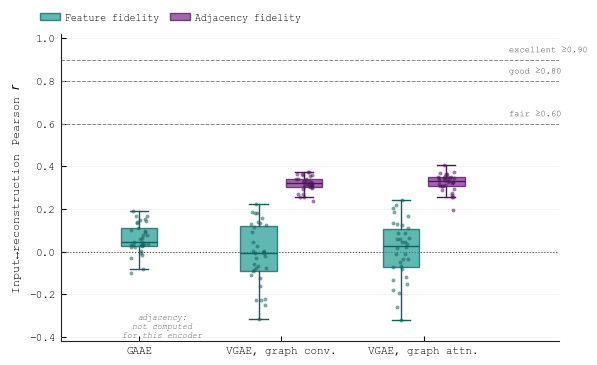

✓ Figure 11 saved successfully.


In [5]:
fig, ax = plt.subplots(figsize=(150 * MM, 90 * MM))

encoder_labels = ['GAAE', 'VGAE, graph conv.', 'VGAE, graph attn.']
x_positions = {label: i for i, label in enumerate(encoder_labels)}
box_width = 0.32
rng = np.random.default_rng(0)

box_artists = []
for label in encoder_labels:
    x0 = x_positions[label]
    d_test = fidelity[label]['test']
    feat_key = 'feature_fidelity_r' if 'feature_fidelity_r' in d_test else 'recon_fidelity_r'
    feat_vals = np.asarray(d_test[feat_key], dtype=float)
    has_adjacency = label != 'GAAE'

    feat_x = x0 - box_width / 2 if has_adjacency else x0
    bp = ax.boxplot([feat_vals], positions=[feat_x], widths=box_width * 0.8, patch_artist=True,
                     showfliers=False, zorder=3)
    for patch in bp['boxes']:
        patch.set_facecolor(COLOR_FEATURE_FILL); patch.set_edgecolor(COLOR_FEATURE_EDGE); patch.set_alpha(0.75)
    for element in ('whiskers', 'caps', 'medians'):
        for artist in bp[element]:
            artist.set_color(COLOR_FEATURE_EDGE)
    jitter = rng.uniform(-0.06, 0.06, size=len(feat_vals))
    ax.scatter(feat_x + jitter, feat_vals, s=8, color=COLOR_FEATURE_EDGE, alpha=0.55, zorder=4, linewidth=0)

    if has_adjacency:
        adj_vals = np.asarray(d_test['recon_fidelity_r'], dtype=float)
        adj_x = x0 + box_width / 2
        bp2 = ax.boxplot([adj_vals], positions=[adj_x], widths=box_width * 0.8, patch_artist=True,
                          showfliers=False, zorder=3)
        for patch in bp2['boxes']:
            patch.set_facecolor(COLOR_ADJACENCY_FILL); patch.set_edgecolor(COLOR_ADJACENCY_EDGE); patch.set_alpha(0.75)
        for element in ('whiskers', 'caps', 'medians'):
            for artist in bp2[element]:
                artist.set_color(COLOR_ADJACENCY_EDGE)
        jitter2 = rng.uniform(-0.06, 0.06, size=len(adj_vals))
        ax.scatter(adj_x + jitter2, adj_vals, s=8, color=COLOR_ADJACENCY_EDGE, alpha=0.55, zorder=4, linewidth=0)
    else:
        ax.text(x0 + box_width / 2, -0.35, 'adjacency:\nnot computed\nfor this encoder',
                ha='center', va='center', fontsize=6, fontstyle='italic', color='#666666')

import matplotlib.patheffects as pe
for thr, name in [(0.60, 'fair'), (0.80, 'good'), (0.90, 'excellent')]:
    ax.axhline(thr, color='#888888', linestyle='--', linewidth=0.7, zorder=1)
    ax.text(2.60, thr + 0.025, f'{name} ≥{thr:.2f}', fontsize=6.3, color='#555555',
            va='bottom', ha='left', zorder=8,
            path_effects=[pe.withStroke(linewidth=2.2, foreground='white', alpha=0.85)])

ax.axhline(0.0, color='#444444', linestyle=':', linewidth=0.8, zorder=1)

ax.set_xticks(list(x_positions.values()))
ax.set_xticklabels(encoder_labels, fontsize=7.8)
ax.set_ylabel('Input↔reconstruction Pearson $r$')
ax.set_xlim(-0.55, 2.95)
ax.set_ylim(-0.42, 1.02)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)
ax.spines['left'].set_color('#222222')
ax.spines['bottom'].set_color('#222222')
ax.grid(axis='y', linestyle='-', alpha=0.15, color='#888888', linewidth=0.5)
ax.set_axisbelow(True)

from matplotlib.patches import Patch
legend_handles = [
    Patch(facecolor=COLOR_FEATURE_FILL, edgecolor=COLOR_FEATURE_EDGE, alpha=0.75, label='Feature fidelity'),
    Patch(facecolor=COLOR_ADJACENCY_FILL, edgecolor=COLOR_ADJACENCY_EDGE, alpha=0.75, label='Adjacency fidelity'),
]
ax.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.22, 1.01),
          ncol=2, fontsize=7, handletextpad=0.5, columnspacing=1.2)

fig.tight_layout(pad=0.4)

for out_dir in OUTPUT_DIRS:
    fig.savefig(out_dir / 'fig11_reconstruction_fidelity.pdf', facecolor='white', edgecolor='none')
    fig.savefig(out_dir / 'fig11_reconstruction_fidelity.png', dpi=600, facecolor='white', edgecolor='none')

plt.show()
print('✓ Figure 11 saved successfully.')
